# LSTM — Groundwater Level Forecasting

- **Architecture:** Stacked LSTM (128 → 64) + Dense(32) → Dense(1)
- **Forecasting:** Single-step (predict one month ahead)
- **Lookback:** 24 months
- **Hyperparameter tuning:** Bayesian Optimisation via Keras Tuner


## 1. Imports & Configuration

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

# ── Config ────────────────────────────────────────────────────────────────────
FEATURES  = ['water_level', 'temperature', 'precipitation', 'wind_speed']
TARGET    = 'water_level'
LOOK_BACK = 24   # months of history the model sees
HORIZON   = 1    # months ahead to predict (single-step)

print(f'TensorFlow  : {tf.__version__}')
print(f'Look back   : {LOOK_BACK} months')
print(f'Horizon     : {HORIZON} month (single-step)')

TensorFlow  : 2.19.0
Look back   : 24 months
Horizon     : 1 month (single-step)


## 2. Data Loading

In [ ]:
def load_and_prepare(path):
    df = pd.read_csv(path)
    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date').asfreq('MS')
    return df

train    = load_and_prepare('uk_train.csv')
validate = load_and_prepare('uk_validate.csv')
test     = load_and_prepare('uk_test.csv')

assert train.index.max()    < validate.index.min(), 'LEAKAGE: train/validate overlap'
assert validate.index.max() < test.index.min(),     'LEAKAGE: validate/test overlap'

print(f'Train    : {train.index.min().date()} → {train.index.max().date()}  ({len(train)} months)')
print(f'Validate : {validate.index.min().date()} → {validate.index.max().date()}  ({len(validate)} months)')
print(f'Test     : {test.index.min().date()}  → {test.index.max().date()}   ({len(test)} months)')

Train    : 1944-01-01 → 2007-10-01  (766 months)
Validate : 2007-11-01 → 2015-10-01  (96 months)
Test     : 2015-11-01  → 2023-10-01   (96 months)


## 3. Scaling

Scalers fitted on **train only** — never on validate or test.

In [ ]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

scaler_X.fit(train[FEATURES])
scaler_y.fit(train[[TARGET]])

X_train_scaled = scaler_X.transform(train[FEATURES])
X_val_scaled   = scaler_X.transform(validate[FEATURES])
X_test_scaled  = scaler_X.transform(test[FEATURES])

y_train_scaled = scaler_y.transform(train[[TARGET]]).flatten()
y_val_scaled   = scaler_y.transform(validate[[TARGET]]).flatten()
y_test_scaled  = scaler_y.transform(test[[TARGET]]).flatten()

print('Shapes after scaling:')
print(f'  X_train: {X_train_scaled.shape}  y_train: {y_train_scaled.shape}')
print(f'  X_val  : {X_val_scaled.shape}  y_val  : {y_val_scaled.shape}')
print(f'  X_test : {X_test_scaled.shape}  y_test : {y_test_scaled.shape}')

Shapes after scaling:
  X_train: (766, 4)  y_train: (766,)
  X_val  : (96, 4)  y_val  : (96,)
  X_test : (96, 4)  y_test : (96,)


## 4. Sequence Construction

In [ ]:
def create_sequences(X, y, look_back=LOOK_BACK, horizon=HORIZON):
    X_seq, y_seq = [], []
    for i in range(len(X) - look_back - horizon + 1):
        X_seq.append(X[i : i + look_back])
        y_seq.append(y[i + look_back + horizon - 1])
    return np.array(X_seq), np.array(y_seq)


def create_sequences_with_buffer(X_buf, y_buf, X_split, y_split,
                                  look_back=LOOK_BACK, horizon=HORIZON):
    """
    Prepend the last look_back rows of the previous split as a buffer
    so the first sequences have proper historical context.
    Buffer rows are discarded from the output.
    """
    X_context = np.vstack([X_buf[-look_back:], X_split])
    y_context = np.concatenate([y_buf[-look_back:], y_split])
    X_seq, y_seq = [], []
    for i in range(len(X_context) - look_back - horizon + 1):
        X_seq.append(X_context[i : i + look_back])
        y_seq.append(y_context[i + look_back + horizon - 1])
    return np.array(X_seq), np.array(y_seq)


X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled)

X_val_seq, y_val_seq = create_sequences_with_buffer(
    X_train_scaled, y_train_scaled,
    X_val_scaled,   y_val_scaled
)

X_trainval = np.vstack([X_train_scaled, X_val_scaled])
y_trainval = np.concatenate([y_train_scaled, y_val_scaled])

X_test_seq, y_test_seq = create_sequences_with_buffer(
    X_trainval, y_trainval,
    X_test_scaled, y_test_scaled
)

print('Sequence shapes:')
print(f'  X_train_seq: {X_train_seq.shape}  y_train_seq: {y_train_seq.shape}')
print(f'  X_val_seq  : {X_val_seq.shape}    y_val_seq  : {y_val_seq.shape}')
print(f'  X_test_seq : {X_test_seq.shape}   y_test_seq : {y_test_seq.shape}')

Sequence shapes:
  X_train_seq: (742, 24, 4)  y_train_seq: (742,)
  X_val_seq  : (96, 24, 4)    y_val_seq  : (96,)
  X_test_seq : (96, 24, 4)   y_test_seq : (96,)


## 5. Baseline Model

In [ ]:
look_back  = X_train_seq.shape[1]
n_features = X_train_seq.shape[2]

model = Sequential([
    Input(shape=(look_back, n_features)),
    LSTM(128, return_sequences=True),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 128)        │        68,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,617 (467.25 KB)

 Trainable params: 119,617 (467.25 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Baseline Training

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=20,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=10, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_lstm.keras', monitor='val_loss',
                    save_best_only=True, verbose=0)
]

history = model.fit(
    X_train_seq, y_train_seq,
    validation_data = (X_val_seq, y_val_seq),
    epochs          = 200,
    batch_size      = 32,
    callbacks       = callbacks,
    verbose         = 1
)

Epoch 1/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.0497 - mae: 0.1702 - val_loss: 0.0121 - val_mae: 0.0861 - learning_rate: 0.0010
Epoch 2/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0202 - mae: 0.1119 - val_loss: 0.0062 - val_mae: 0.0654 - learning_rate: 0.0010
Epoch 3/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0186 - mae: 0.1054 - val_loss: 0.0059 - val_mae: 0.0606 - learning_rate: 0.0010
Epoch 4/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0176 - mae: 0.1011 - val_loss: 0.0070 - val_mae: 0.0624 - learning_rate: 0.0010
Epoch 5/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0167 - mae: 0.1008 - val_loss: 0.0056 - val_mae: 0.0577 - learning_rate: 0.0010
Epoch 6/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0162 - mae: 0.0980 - val_loss: 0.0067 - val_mae: 0.0596 - learning_rate: 0.0010
Epoch 7/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0155 - mae: 0.0967 - val_loss: 0.0048 - val_mae: 0.0531 - learning_rate: 0.0010
Epoch 

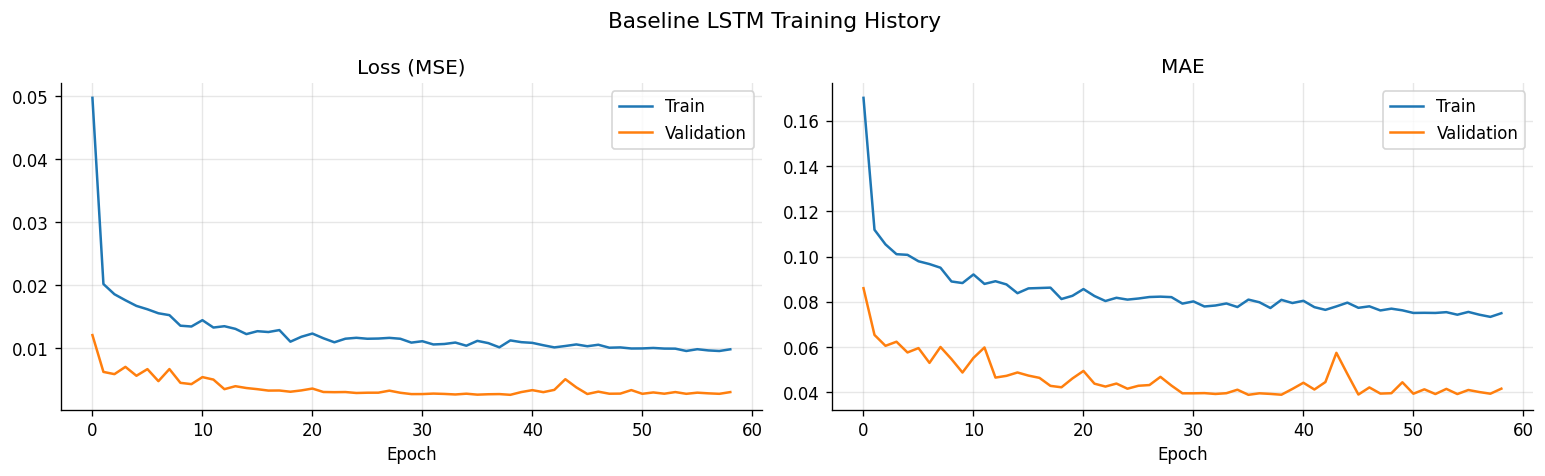

Stopped at epoch: 59


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_title('Loss (MSE)')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].plot(history.history['mae'],     label='Train')
axes[1].plot(history.history['val_mae'], label='Validation')
axes[1].set_title('MAE')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.suptitle('Baseline LSTM Training History', fontsize=13)
plt.tight_layout()
plt.savefig('fig_lstm_training.png', bbox_inches='tight')
plt.show()
print(f'Stopped at epoch: {len(history.history["loss"])}')

## 7. Baseline Evaluation

In [ ]:
def safe_mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom  = np.where(np.abs(y_true) < eps, np.nan, y_true)
    return np.nanmean(np.abs((y_true - y_pred) / denom)) * 100

def get_metrics(y_true, y_pred, label):
    return pd.Series({
        'RMSE'    : np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE'     : mean_absolute_error(y_true, y_pred),
        'MAPE (%)': safe_mape(y_true, y_pred),
        'R²'      : r2_score(y_true, y_pred),
        'NSE'     : 1 - np.sum((y_true - y_pred)**2) /
                        np.sum((y_true - y_true.mean())**2),
    }, name=label).round(4)

def get_peak_metrics(y_true, y_pred):
    thresh = np.percentile(y_true, 90)
    mask   = y_true >= thresh
    return pd.Series({
        'Threshold (90th pct)': round(thresh, 4),
        'N peak samples'      : int(mask.sum()),
        'Peak RMSE'           : round(np.sqrt(mean_squared_error(y_true[mask], y_pred[mask])), 4),
        'Peak MAE'            : round(mean_absolute_error(y_true[mask], y_pred[mask]), 4),
        'Avg bias (Act-Pred)' : round((y_true[mask] - y_pred[mask]).mean(), 4),
    })

# Load best model and predict
best_model = load_model('best_lstm.keras')
y_pred_scaled = best_model.predict(X_test_seq).flatten()
y_pred_test   = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_true_test   = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

baseline_metrics = get_metrics(y_true_test, y_pred_test, 'LSTM (baseline)')
baseline_peak    = get_peak_metrics(y_true_test, y_pred_test)

print('=== BASELINE TEST METRICS ===')
print(baseline_metrics.to_string())
print('\n=== PEAK PERFORMANCE (≥ 90th percentile) ===')
print(baseline_peak.to_string())

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step 
=== BASELINE TEST METRICS ===
RMSE        3.0670
MAE         2.5068
MAPE (%)    3.8520
R²          0.5104
NSE         0.5104

=== PEAK PERFORMANCE (≥ 90th percentile) ===
Threshold (90th pct)    73.0418
N peak samples          10.0000
Peak RMSE                2.6262
Peak MAE                 2.2074
Avg bias (Act-Pred)      2.2074


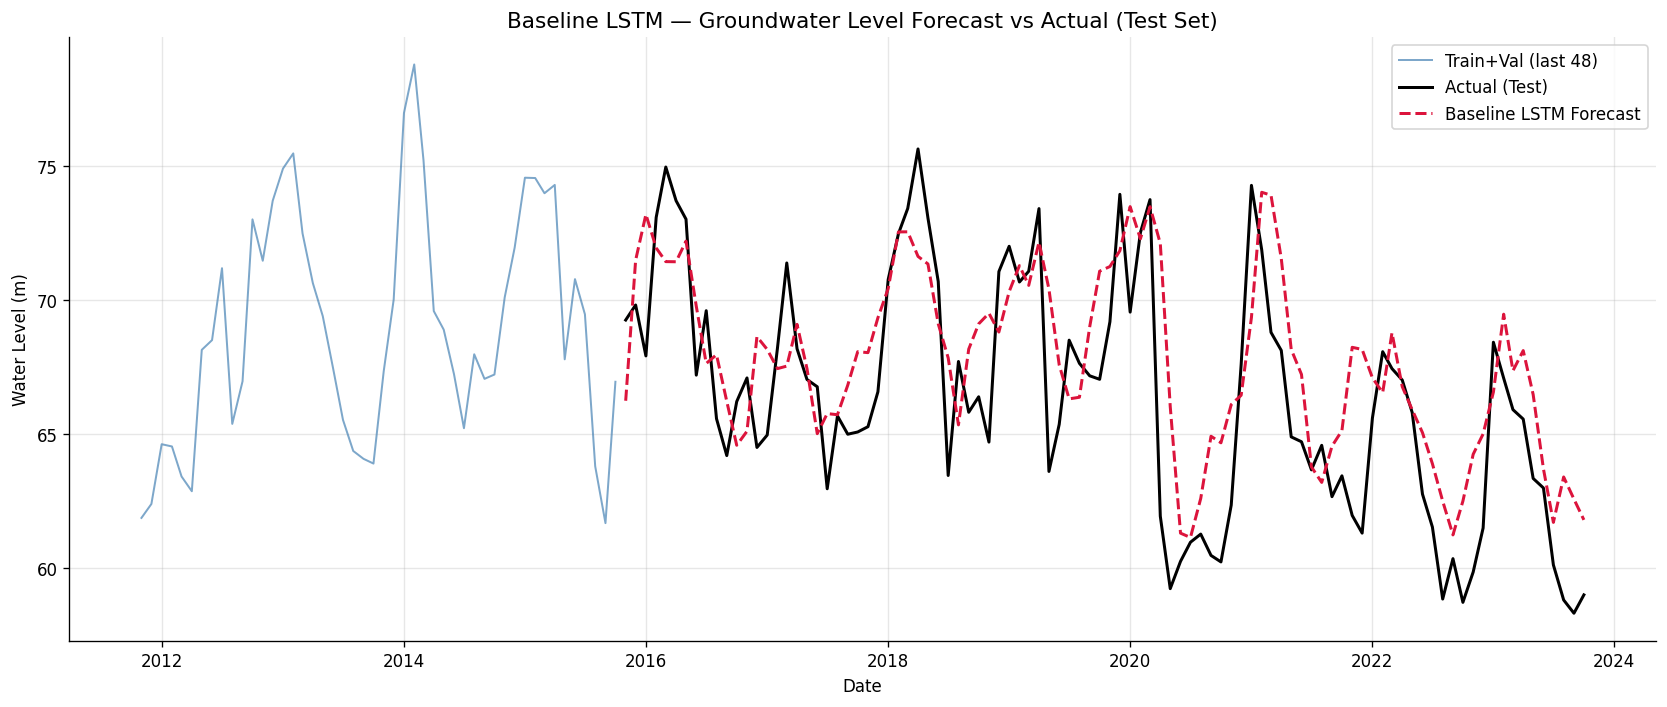

In [ ]:
# Baseline forecast plot
test_dates       = test.index[:len(y_true_test)]
trainval_context = pd.concat([train, validate])[TARGET].iloc[-48:]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(trainval_context.index, trainval_context.values,
        color='steelblue', lw=1.2, alpha=0.7, label='Train+Val (last 48)')
ax.plot(test_dates, y_true_test,
        color='black', lw=1.8, label='Actual (Test)')
ax.plot(test_dates, y_pred_test,
        color='crimson', lw=1.8, linestyle='--', label='Baseline LSTM Forecast')
ax.set_title('Baseline LSTM — Groundwater Level Forecast vs Actual (Test Set)', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Water Level (m)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_lstm_baseline_forecast.png', bbox_inches='tight')
plt.show()

## 8. Hyperparameter Tuning (Bayesian Optimisation)

In [ ]:
!pip install keras-tuner
import keras_tuner as kt

def build_model(hp):
    n_layers = hp.Int('n_layers',   min_value=1,   max_value=2,   step=1)
    units_1  = hp.Choice('units_1', values=[64, 128, 256])
    units_2  = hp.Choice('units_2', values=[32, 64, 128])
    dropout  = hp.Float('dropout',  min_value=0.1, max_value=0.3, step=0.1)
    lr       = hp.Float('lr',       min_value=1e-4, max_value=1e-3, sampling='log')

    m = Sequential()
    m.add(Input(shape=(look_back, n_features)))

    if n_layers == 1:
        m.add(LSTM(units_1, return_sequences=False))
        m.add(Dropout(dropout))
    else:
        m.add(LSTM(units_1, return_sequences=True))
        m.add(Dropout(dropout))
        m.add(LSTM(units_2, return_sequences=False))
        m.add(Dropout(dropout))

    m.add(Dense(32, activation='relu'))
    m.add(Dense(1))
    m.compile(optimizer=Adam(learning_rate=lr), loss='mse', metrics=['mae'])
    return m

print('Search space defined.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 15.0 MB/s eta 0:00:00
Search space defined.


In [ ]:
search_callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

best_val_loss = float('inf')
best_batch    = 32
best_hp       = None
best_tuner    = None

for bs in [16, 32]:   # removed 64 — less impactful for this dataset size
    print(f'\n── batch_size={bs} ──')
    tuner_bs = kt.BayesianOptimization(
        hypermodel         = build_model,
        objective          = kt.Objective('val_loss', direction='min'),
        max_trials         = 10,   # was 20
        num_initial_points = 3,
        directory          = 'kt_tuning',
        project_name       = f'lstm_gwl_bs{bs}',
        overwrite          = True,
        seed               = SEED
    )
    tuner_bs.search(
        X_train_seq, y_train_seq,
        validation_data = (X_val_seq, y_val_seq),
        epochs          = 50,    # was 150 — enough to compare configs
        batch_size      = bs,
        callbacks       = search_callbacks,
        verbose         = 0
    )
    trial_loss = tuner_bs.oracle.get_best_trials(1)[0].score
    print(f'  Best val_loss: {trial_loss:.6f}')
    if trial_loss < best_val_loss:
        best_val_loss = trial_loss
        best_batch    = bs
        best_hp       = tuner_bs.get_best_hyperparameters(1)[0]
        best_tuner    = tuner_bs

print(f'\nBest batch size : {best_batch}')
print(f'Best val_loss   : {best_val_loss:.6f}')
for k, v in best_hp.values.items():
    print(f'  {k}: {v}')


── batch_size=16 ──
  Best val_loss: 0.002799

── batch_size=32 ──
  Best val_loss: 0.002526

Best batch size : 32
Best val_loss   : 0.002526
  n_layers: 2
  units_1: 64
  units_2: 64
  dropout: 0.1
  lr: 0.0007731576839806804


In [ ]:
# Retrain best config with full callbacks
best_model_tuned = best_tuner.hypermodel.build(best_hp)
best_model_tuned.summary()

tuned_callbacks = [
    EarlyStopping(monitor='val_loss', patience=20,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=10, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_lstm_tuned.keras', monitor='val_loss',
                    save_best_only=True, verbose=0)
]

history_tuned = best_model_tuned.fit(
    X_train_seq, y_train_seq,
    validation_data = (X_val_seq, y_val_seq),
    epochs          = 200,
    batch_size      = best_batch,
    callbacks       = tuned_callbacks,
    verbose         = 1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 24, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,801 (206.25 KB)

 Trainable params: 52,801 (206.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - loss: 0.0553 - mae: 0.1793 - val_loss: 0.0108 - val_mae: 0.0802 - learning_rate: 7.7316e-04
Epoch 2/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0217 - mae: 0.1167 - val_loss: 0.0076 - val_mae: 0.0655 - learning_rate: 7.7316e-04
Epoch 3/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0182 - mae: 0.1033 - val_loss: 0.0060 - val_mae: 0.0620 - learning_rate: 7.7316e-04
Epoch 4/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0173 - mae: 0.1016 - val_loss: 0.0057 - val_mae: 0.0610 - learning_rate: 7.7316e-04
Epoch 5/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.0171 - mae: 0.1002 - val_loss: 0.0056 - val_mae: 0.0591 - learning_rate: 7.7316e-04
Epoch 6/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0170 - mae: 0.1005 - val_loss: 0.0055 - val_mae: 0.0617 - learning_rate: 7.7316e-04
Epoch 7/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0174 - mae: 0.1025 - val_loss: 0.0060 - val_mae: 0.0658 - lear

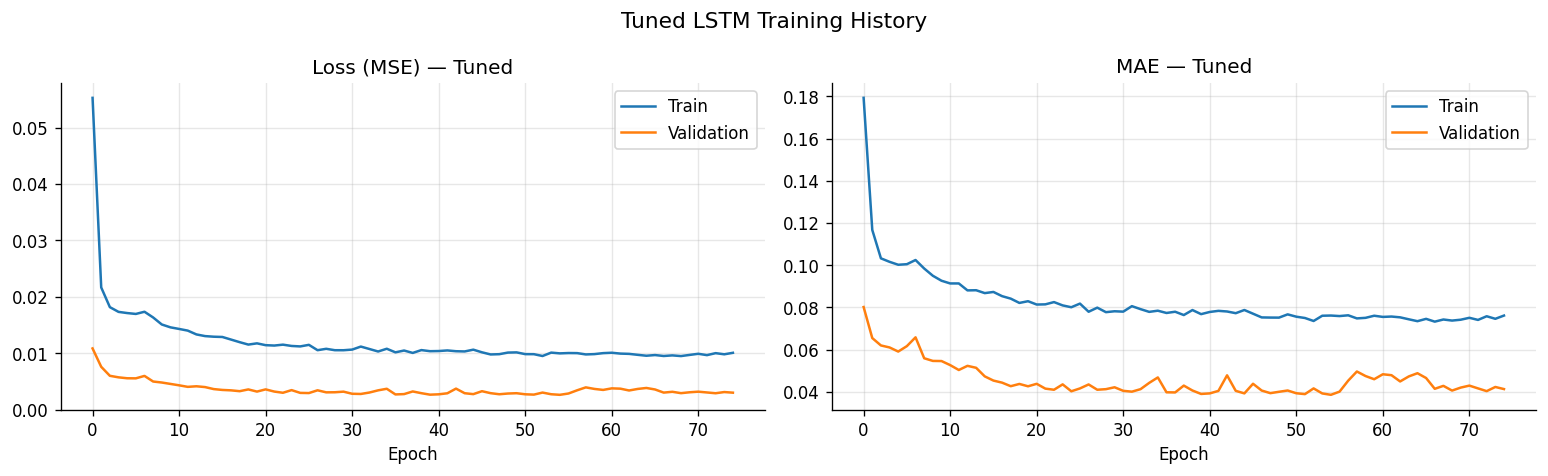

In [ ]:
# Training curves — tuned
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history_tuned.history['loss'],     label='Train')
axes[0].plot(history_tuned.history['val_loss'], label='Validation')
axes[0].set_title('Loss (MSE) — Tuned')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].plot(history_tuned.history['mae'],     label='Train')
axes[1].plot(history_tuned.history['val_mae'], label='Validation')
axes[1].set_title('MAE — Tuned')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.suptitle('Tuned LSTM Training History', fontsize=13)
plt.tight_layout()
plt.savefig('fig_lstm_tuned_training.png', bbox_inches='tight')
plt.show()

## 9. Tuned Model Evaluation

In [ ]:
tuned_model     = load_model('best_lstm_tuned.keras')
y_pred_tuned_sc = tuned_model.predict(X_test_seq).flatten()
y_pred_tuned    = scaler_y.inverse_transform(y_pred_tuned_sc.reshape(-1, 1)).flatten()

# y_true_test already defined in Section 7
tuned_metrics = get_metrics(y_true_test, y_pred_tuned, 'LSTM (tuned)')
tuned_peak    = get_peak_metrics(y_true_test, y_pred_tuned)

# Baseline vs tuned comparison
comparison = pd.DataFrame([baseline_metrics, tuned_metrics]).T
comparison.columns = ['Baseline LSTM', 'Tuned LSTM']
print('=== BASELINE vs TUNED ===')
print(comparison.to_string())

# Pick the better model for downstream use
if tuned_metrics['RMSE'] < baseline_metrics['RMSE']:
    final_metrics = tuned_metrics
    final_pred    = y_pred_tuned
    final_label   = 'Tuned LSTM'
    print('\n→ Tuned model selected (lower RMSE)')
else:
    final_metrics = baseline_metrics
    final_pred    = y_pred_test
    final_label   = 'Baseline LSTM'
    print('\n→ Baseline model selected (lower RMSE)')

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step 
=== BASELINE vs TUNED ===
          Baseline LSTM  Tuned LSTM
RMSE             3.0670      2.9386
MAE              2.5068      2.3970
MAPE (%)         3.8520      3.6710
R²               0.5104      0.5505
NSE              0.5104      0.5505

→ Tuned model selected (lower RMSE)


## 10. Forecast Plot & Error Analysis

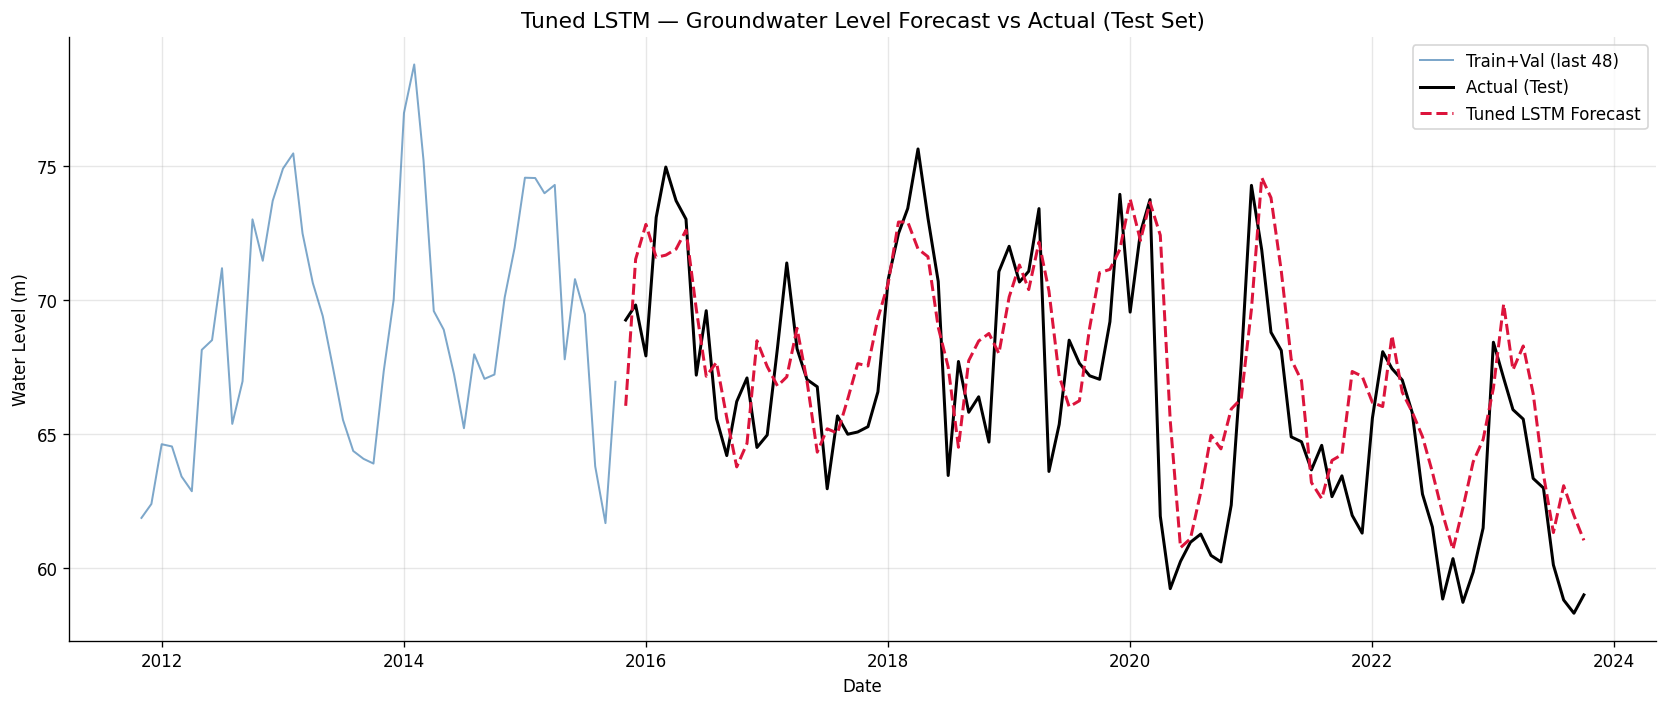

In [ ]:
test_dates       = test.index[:len(y_true_test)]
trainval_context = pd.concat([train, validate])[TARGET].iloc[-48:]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(trainval_context.index, trainval_context.values,
        color='steelblue', lw=1.2, alpha=0.7, label='Train+Val (last 48)')
ax.plot(test_dates, y_true_test,
        color='black', lw=1.8, label='Actual (Test)')
ax.plot(test_dates, final_pred,
        color='crimson', lw=1.8, linestyle='--', label=f'{final_label} Forecast')
ax.set_title(f'{final_label} — Groundwater Level Forecast vs Actual (Test Set)', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Water Level (m)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_lstm_forecast.png', bbox_inches='tight')
plt.show()

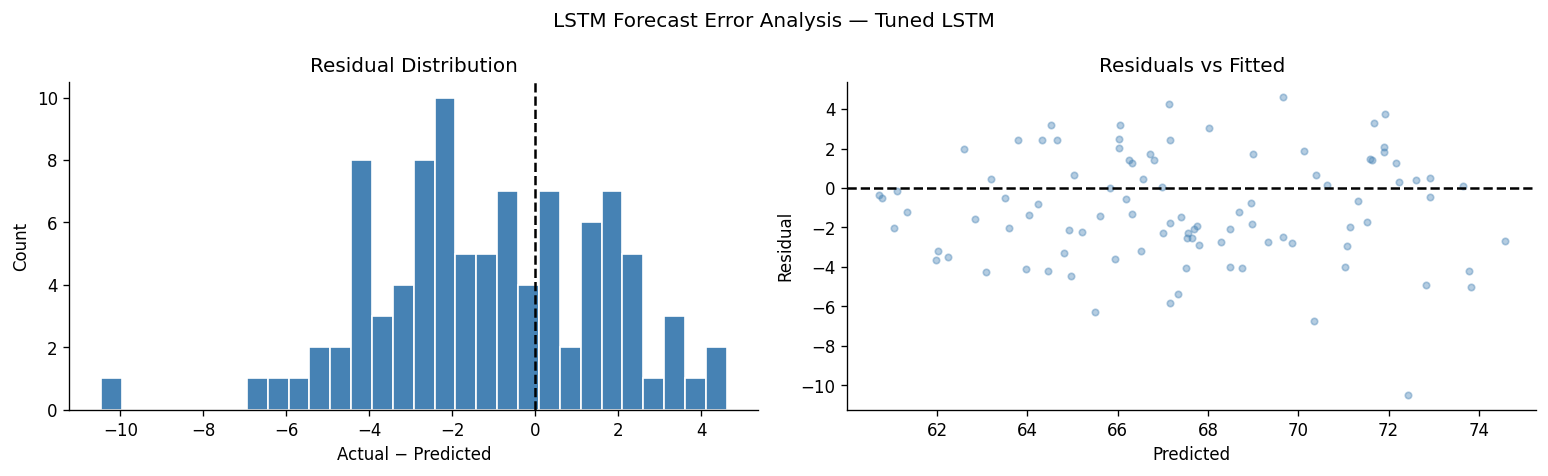

In [ ]:
errors = y_true_test - final_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(errors, bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='black', lw=1.5, linestyle='--')
axes[0].set_title('Residual Distribution')
axes[0].set_xlabel('Actual − Predicted')
axes[0].set_ylabel('Count')
axes[1].scatter(final_pred, errors, alpha=0.4, s=15, color='steelblue')
axes[1].axhline(0, color='black', lw=1.5, linestyle='--')
axes[1].set_title('Residuals vs Fitted')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residual')
plt.suptitle(f'LSTM Forecast Error Analysis — {final_label}', fontsize=12)
plt.tight_layout()
plt.savefig('fig_lstm_errors.png', bbox_inches='tight')
plt.show()

## 11. Benchmark Table & Findings Summary

In [ ]:
# Update benchmark CSV
try:
    bench = pd.read_csv('table3_benchmark_metrics.csv', index_col=0)
except FileNotFoundError:
    bench = pd.DataFrame()

bench['LSTM (baseline)'] = baseline_metrics
bench['LSTM (tuned)']    = tuned_metrics
bench.to_csv('table3_benchmark_metrics.csv')

print('=== BENCHMARK TABLE ===')
print(bench.to_string())

print('\n\n' + '=' * 65)
print('LSTM FINDINGS SUMMARY')
print('=' * 65)
print(f"""
Selected model  : {final_label}
Architecture    : Stacked LSTM ({best_hp.get('units_1') if final_label != 'Baseline LSTM' else 128} →
                  {best_hp.get('units_2') if final_label != 'Baseline LSTM' else 64}) + Dense(32) → Dense(1)
Input features  : {FEATURES}
Look back       : {LOOK_BACK} months
Horizon         : {HORIZON} month (single-step)
Training period : {train.index.min().date()} → {validate.index.max().date()}
Test period     : {test.index.min().date()} → {test.index.max().date()}

--- Final Test Metrics ---
RMSE      : {final_metrics['RMSE']}
MAE       : {final_metrics['MAE']}
MAPE (%)  : {final_metrics['MAPE (%)']}
R²        : {final_metrics['R²']}
NSE       : {final_metrics['NSE']}

--- Saved Outputs ---
fig_lstm_training.png        — baseline training curves
fig_lstm_tuned_training.png  — tuned training curves
fig_lstm_forecast.png        — forecast vs actual
fig_lstm_errors.png          — error distribution
table3_benchmark_metrics.csv — updated with LSTM columns
""")
print('=' * 65)

=== BENCHMARK TABLE ===
          LSTM (baseline)  LSTM (tuned)
RMSE               3.0670        2.9386
MAE                2.5068        2.3970
MAPE (%)           3.8520        3.6710
R²                 0.5104        0.5505
NSE                0.5104        0.5505


LSTM FINDINGS SUMMARY

Selected model  : Tuned LSTM
Architecture    : Stacked LSTM (64 →
                  64) + Dense(32) → Dense(1)
Input features  : ['water_level', 'temperature', 'precipitation', 'wind_speed']
Look back       : 24 months
Horizon         : 1 month (single-step)
Training period : 1944-01-01 → 2015-10-01
Test period     : 2015-11-01 → 2023-10-01

--- Final Test Metrics ---
RMSE      : 2.9386
MAE       : 2.397
MAPE (%)  : 3.671
R²        : 0.5505
NSE       : 0.5505

--- Saved Outputs ---
fig_lstm_training.png        — baseline training curves
fig_lstm_tuned_training.png  — tuned training curves
fig_lstm_forecast.png        — forecast vs actual
fig_lstm_errors.png          — error distribution
table3_benchmar

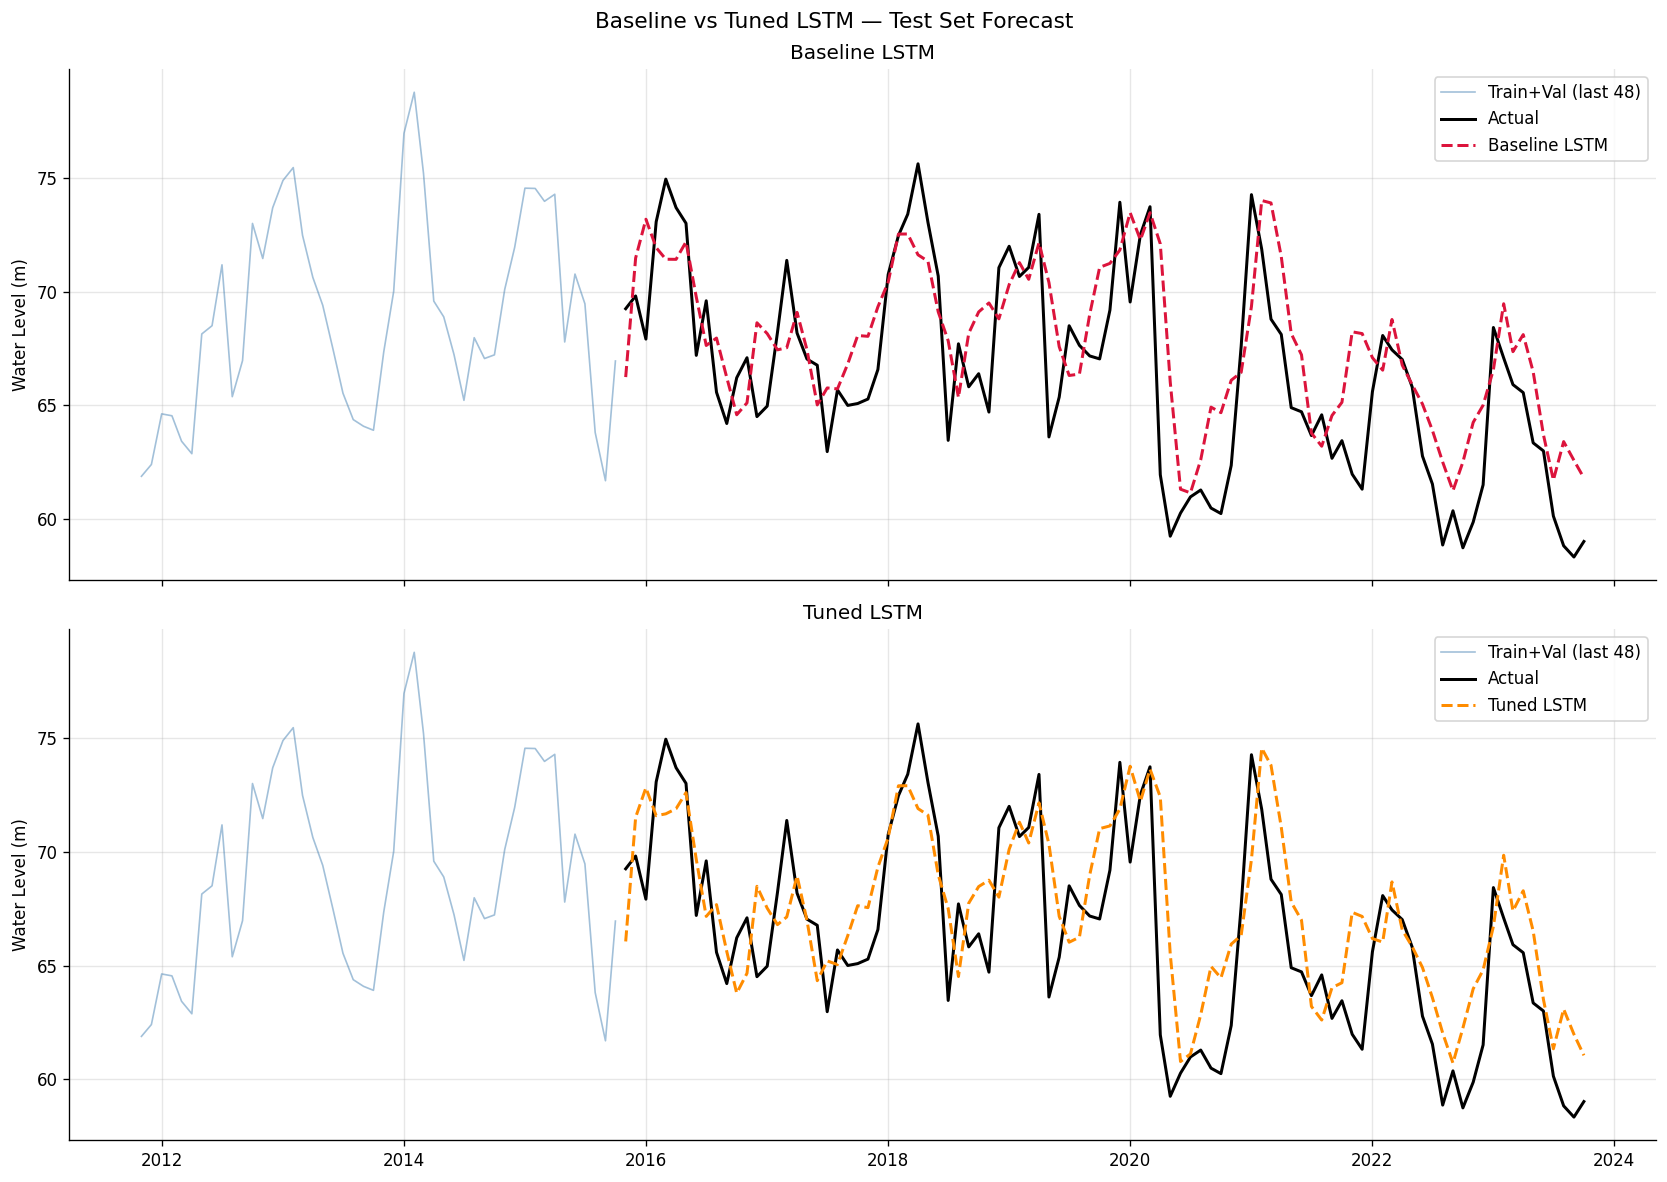

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for ax, pred, label, color in zip(
    axes,
    [y_pred_test, y_pred_tuned],
    ['Baseline LSTM', 'Tuned LSTM'],
    ['crimson', 'darkorange']
):
    ax.plot(trainval_context.index, trainval_context.values,
            color='steelblue', lw=1.0, alpha=0.5, label='Train+Val (last 48)')
    ax.plot(test_dates, y_true_test,
            color='black', lw=1.8, label='Actual')
    ax.plot(test_dates, pred,
            color=color, lw=1.8, linestyle='--', label=label)
    ax.set_title(label)
    ax.set_ylabel('Water Level (m)')
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].xaxis.set_major_locator(mdates.YearLocator(2))
plt.suptitle('Baseline vs Tuned LSTM — Test Set Forecast', fontsize=13)
plt.tight_layout()
plt.savefig('fig_lstm_comparison.png', bbox_inches='tight')
plt.show()

# Hugging face uplod

In [ ]:
import os
import json
import shutil
import joblib
from pathlib import Path
from huggingface_hub import HfApi, create_repo

from google.colab import userdata


# ── Fill these in ─────────────────────────────────────────────────────────────
HF_USERNAME = 'kozy9'
REPO_NAME   = 'GWLSTM'
HF_TOKEN    = userdata.get('Huggingface')  # your write token
# ─────────────────────────────────────────────────────────────────────────────

REPO_ID   = f'{HF_USERNAME}/{REPO_NAME}'
LOCAL_DIR = Path('hf_upload_lstm')
LOCAL_DIR.mkdir(exist_ok=True)

print(f'Preparing upload to: https://huggingface.co/{REPO_ID}')

Preparing upload to: https://huggingface.co/kozy9/GWLSTM


In [ ]:
# ── 1. Save best model & scalers ──────────────────────────────────────────────
# Copy the best saved keras model
shutil.copy('best_lstm_tuned.keras', LOCAL_DIR / 'lstm_model.keras')
print(f'Model saved  →  {LOCAL_DIR}/lstm_model.keras')

# Save scalers
joblib.dump(scaler_X, LOCAL_DIR / 'scaler_X.pkl')
joblib.dump(scaler_y, LOCAL_DIR / 'scaler_y.pkl')
print(f'Scalers saved →  scaler_X.pkl, scaler_y.pkl')

Model saved  →  hf_upload_lstm/lstm_model.keras
Scalers saved →  scaler_X.pkl, scaler_y.pkl


In [ ]:
# ── 2. Save model config & metrics ────────────────────────────────────────────
config = {
    'model_type'      : 'LSTM',
    'architecture'    : 'LSTM(128) → Dropout(0.1) → Dense(32) → Dense(1)',
    'framework'       : 'TensorFlow/Keras',
    'task'            : 'Single-step monthly groundwater level forecasting',
    'features'        : FEATURES,
    'target'          : TARGET,
    'lookback_months' : LOOK_BACK,
    'horizon_months'  : HORIZON,
    'tuning': {
        'method'      : 'Bayesian Optimisation (Keras Tuner)',
        'n_trials'    : 20,
        'best_config' : {
            'n_layers'  : int(best_hp.get('n_layers')),
            'units_1'   : int(best_hp.get('units_1')),
            'dropout'   : float(best_hp.get('dropout')),
            'lr'        : float(best_hp.get('lr')),
            'batch_size': int(best_batch),
        }
    },
    'data_splits': {
        'train'     : {'start': str(train.index.min().date()), 'end': str(train.index.max().date()), 'n_months': len(train)},
        'validation': {'start': str(validate.index.min().date()), 'end': str(validate.index.max().date()), 'n_months': len(validate)},
        'test'      : {'start': str(test.index.min().date()), 'end': str(test.index.max().date()), 'n_months': len(test)},
    },
    'test_metrics': {
        'RMSE'    : round(float(tuned_metrics['RMSE']),     4),
        'MAE'     : round(float(tuned_metrics['MAE']),      4),
        'MAPE_pct': round(float(tuned_metrics['MAPE (%)']), 4),
        'R2'      : round(float(tuned_metrics['R²']),       4),
        'NSE'     : round(float(tuned_metrics['NSE']),      4),
    },
    'notes': 'Scaler fitted on train only. Oracle exog assumption — contemporaneous met vars used at forecast time.'
}

config_path = LOCAL_DIR / 'model_config.json'
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)

print(f'Config saved →  {config_path}')
print(json.dumps(config, indent=2))

Config saved →  hf_upload_lstm/model_config.json
{
  "model_type": "LSTM",
  "architecture": "LSTM(128) \u2192 Dropout(0.1) \u2192 Dense(32) \u2192 Dense(1)",
  "framework": "TensorFlow/Keras",
  "task": "Single-step monthly groundwater level forecasting",
  "features": [
    "water_level",
    "temperature",
    "precipitation",
    "wind_speed"
  ],
  "target": "water_level",
  "lookback_months": 24,
  "horizon_months": 1,
  "tuning": {
    "method": "Bayesian Optimisation (Keras Tuner)",
    "n_trials": 20,
    "best_config": {
      "n_layers": 2,
      "units_1": 64,
      "dropout": 0.1,
      "lr": 0.0007731576839806804,
      "batch_size": 32
    }
  },
  "data_splits": {
    "train": {
      "start": "1944-01-01",
      "end": "2007-10-01",
      "n_months": 766
    },
    "validation": {
      "start": "2007-11-01",
      "end": "2015-10-01",
      "n_months": 96
    },
    "test": {
      "start": "2015-11-01",
      "end": "2023-10-01",
      "n_months": 96
    }
  },
  "te

In [ ]:
# ── 3. Write inference.py ─────────────────────────────────────────────────────
inference_code = '''
"""
inference.py — LSTM Groundwater Level Forecasting
==================================================
Usage
-----
    from inference import load_model, forecast
    model, scaler_X, scaler_y = load_model()
    prediction = forecast(model, scaler_X, scaler_y, X_window)
"""

import json
import joblib
import numpy as np
import pandas as pd
from pathlib import Path
from tensorflow.keras.models import load_model as keras_load

MODEL_PATH    = Path(__file__).parent / "lstm_model.keras"
SCALER_X_PATH = Path(__file__).parent / "scaler_X.pkl"
SCALER_Y_PATH = Path(__file__).parent / "scaler_y.pkl"
CONFIG_PATH   = Path(__file__).parent / "model_config.json"


def load_model():
    """Load the LSTM model and both scalers."""
    model    = keras_load(MODEL_PATH)
    scaler_X = joblib.load(SCALER_X_PATH)
    scaler_y = joblib.load(SCALER_Y_PATH)
    print("LSTM model and scalers loaded.")
    return model, scaler_X, scaler_y


def load_config():
    with open(CONFIG_PATH) as f:
        return json.load(f)


def forecast(model, scaler_X, scaler_y, X_window: pd.DataFrame):
    """
    Predict the next month\'s groundwater level.

    Parameters
    ----------
    model     : loaded Keras model
    scaler_X  : fitted MinMaxScaler for features
    scaler_y  : fitted MinMaxScaler for target
    X_window  : DataFrame with columns [water_level, temperature,
                precipitation, wind_speed] and exactly 24 rows
                (the lookback window)

    Returns
    -------
    prediction : float — forecasted water level in original units (m)
    """
    cfg      = load_config()
    required = cfg[\'features\']
    lookback = cfg[\'lookback_months\']

    missing = [c for c in required if c not in X_window.columns]
    if missing:
        raise ValueError(f"X_window is missing columns: {missing}")
    if len(X_window) != lookback:
        raise ValueError(f"X_window must have {lookback} rows, got {len(X_window)}")

    X_scaled = scaler_X.transform(X_window[required])
    X_input  = X_scaled.reshape(1, lookback, len(required))

    y_scaled    = model.predict(X_input, verbose=0).flatten()
    prediction  = scaler_y.inverse_transform(y_scaled.reshape(-1, 1)).flatten()[0]

    return float(prediction)


if __name__ == "__main__":
    model, scaler_X, scaler_y = load_model()
    cfg = load_config()
    print(f"Model: {cfg[\'architecture\']}")
    print(f"Test RMSE: {cfg[\'test_metrics\'][\'RMSE\']} m")

    # Dummy window — replace with real data
    import numpy as np
    dummy = pd.DataFrame({
        \'water_level\'  : np.random.uniform(60, 75, 24),
        \'temperature\'  : np.random.uniform(3, 15, 24),
        \'precipitation\': np.random.uniform(20, 120, 24),
        \'wind_speed\'   : np.random.uniform(10, 25, 24),
    })
    pred = forecast(model, scaler_X, scaler_y, dummy)
    print(f"\\nForecast (next month): {pred:.4f} m")
'''

inference_path = LOCAL_DIR / 'inference.py'
inference_path.write_text(inference_code.strip())
print(f'Inference script saved →  {inference_path}')

Inference script saved →  hf_upload_lstm/inference.py


In [ ]:
# ── 4. Write README / model card ──────────────────────────────────────────────
m  = config['test_metrics']
hp = config['tuning']['best_config']

readme = f"""---
license: mit
tags:
  - time-series
  - forecasting
  - lstm
  - hydrology
  - groundwater
---

# LSTM Groundwater Level Forecasting — UK

A tuned LSTM model for single-step monthly groundwater level forecasting
using meteorological variables as exogenous inputs.

## Model Details

| Parameter | Value |
|---|---|
| Architecture | {config['architecture']} |
| Framework | TensorFlow / Keras |
| Task | Single-step monthly forecasting |
| Lookback window | {config['lookback_months']} months |
| Input features | water_level, temperature, precipitation, wind_speed |
| Tuning method | Bayesian Optimisation (Keras Tuner, {config['tuning']['n_trials']} trials) |

## Data Splits

| Split | Period | Months |
|---|---|---|
| Training | {config['data_splits']['train']['start']} → {config['data_splits']['train']['end']} | {config['data_splits']['train']['n_months']} |
| Validation | {config['data_splits']['validation']['start']} → {config['data_splits']['validation']['end']} | {config['data_splits']['validation']['n_months']} |
| Test | {config['data_splits']['test']['start']} → {config['data_splits']['test']['end']} | {config['data_splits']['test']['n_months']} |

## Best Hyperparameters

| Parameter | Value |
|---|---|
| LSTM layers | {hp['n_layers']} |
| Units | {hp['units_1']} |
| Dropout | {hp['dropout']} |
| Learning rate | {hp['lr']:.6f} |
| Batch size | {hp['batch_size']} |

## Test Set Performance

| Metric | Value |
|---|---|
| RMSE | {m['RMSE']} m |
| MAE | {m['MAE']} m |
| MAPE | {m['MAPE_pct']}% |
| R² | {m['R2']} |
| NSE | {m['NSE']} |

> This model is part of a benchmark study comparing SARIMAX, LSTM, and TCN
> for UK groundwater level forecasting.

## Important Note

Contemporaneous meteorological variables are used as inputs at forecast time
(oracle assumption). Future met values are treated as known — consistent with
the experimental setup used across all models in this study.

## Repository Contents

```
├── lstm_model.keras    # Trained Keras model
├── scaler_X.pkl        # Feature scaler (MinMaxScaler)
├── scaler_y.pkl        # Target scaler (MinMaxScaler)
├── model_config.json   # Config, hyperparameters & metrics
├── inference.py        # Load model & generate forecasts
└── README.md           # This file
```

## Quick Start

```python
from huggingface_hub import hf_hub_download
from tensorflow.keras.models import load_model
import joblib, pandas as pd, numpy as np

model    = load_model(hf_hub_download('{REPO_ID}', 'lstm_model.keras'))
scaler_X = joblib.load(hf_hub_download('{REPO_ID}', 'scaler_X.pkl'))
scaler_y = joblib.load(hf_hub_download('{REPO_ID}', 'scaler_y.pkl'))

# Provide a 24-month window of features
X_window = pd.DataFrame({{
    'water_level'  : [...],   # 24 values
    'temperature'  : [...],
    'precipitation': [...],
    'wind_speed'   : [...],
}})

X_scaled = scaler_X.transform(X_window)
X_input  = X_scaled.reshape(1, 24, 4)
y_scaled = model.predict(X_input)
pred     = scaler_y.inverse_transform(y_scaled)[0][0]
print(f'Next month forecast: {{pred:.2f}} m')
```
"""

readme_path = LOCAL_DIR / 'README.md'
readme_path.write_text(readme)
print(f'Model card saved →  {readme_path}')

Model card saved →  hf_upload_lstm/README.md


In [ ]:
# ── 5. Copy figures ───────────────────────────────────────────────────────────
for fig in Path('.').glob('fig_lstm*.png'):
    shutil.copy(fig, LOCAL_DIR / fig.name)
    print(f'Copied {fig.name}')

print('\nFiles ready for upload:')
for f in sorted(LOCAL_DIR.iterdir()):
    print(f'  {f.name}  ({f.stat().st_size / 1024:.1f} KB)')

Copied fig_lstm_tuned_training.png
Copied fig_lstm_baseline_forecast.png
Copied fig_lstm_comparison.png
Copied fig_lstm_forecast.png
Copied fig_lstm_errors.png
Copied fig_lstm_training.png

Files ready for upload:
  README.md  (2.6 KB)
  fig_lstm_baseline_forecast.png  (147.2 KB)
  fig_lstm_comparison.png  (244.9 KB)
  fig_lstm_errors.png  (44.2 KB)
  fig_lstm_forecast.png  (147.6 KB)
  fig_lstm_training.png  (68.4 KB)
  fig_lstm_tuned_training.png  (69.3 KB)
  inference.py  (2.8 KB)
  lstm_model.keras  (659.7 KB)
  model_config.json  (1.2 KB)
  scaler_X.pkl  (1.1 KB)
  scaler_y.pkl  (1.0 KB)


In [ ]:
# ── 6. Create repo & upload ───────────────────────────────────────────────────
api = HfApi()

create_repo(
    repo_id   = REPO_ID,
    token     = HF_TOKEN,
    repo_type = 'model',
    exist_ok  = True,
    private   = False,
)
print(f'Repo ready: https://huggingface.co/{REPO_ID}')

api.upload_folder(
    folder_path    = str(LOCAL_DIR),
    repo_id        = REPO_ID,
    repo_type      = 'model',
    token          = HF_TOKEN,
    commit_message = f'Upload LSTM — test RMSE {config["test_metrics"]["RMSE"]} m  R² {config["test_metrics"]["R2"]}',
)

print(f'\nUpload complete!')
print(f'View at: https://huggingface.co/{REPO_ID}')

Repo ready: https://huggingface.co/kozy9/GWLSTM


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...stm_baseline_forecast.png:  46%|####6     | 69.4kB /  151kB            

  ...m/fig_lstm_comparison.png:  46%|####6     |  115kB /  251kB            

  ...stm/fig_lstm_forecast.png:  46%|####6     | 69.6kB /  151kB            

  ...oad_lstm/lstm_model.keras:  46%|####6     |  311kB /  676kB            

  ..._upload_lstm/scaler_X.pkl:  46%|####5     |   518B / 1.13kB            

  ..._upload_lstm/scaler_y.pkl:  46%|####5     |   448B /   975B            


Upload complete!
View at: https://huggingface.co/kozy9/GWLSTM


# more information about ridual
we will import the model from hugging face so I do not need to re run the code

In [1]:
from huggingface_hub import hf_hub_download
from tensorflow.keras.models import load_model
import joblib, pandas as pd, numpy as np

# Load model and scalers
model    = load_model(hf_hub_download('kozy9/GWLSTM', 'lstm_model.keras'))
scaler_X = joblib.load(hf_hub_download('kozy9/GWLSTM', 'scaler_X.pkl'))
scaler_y = joblib.load(hf_hub_download('kozy9/GWLSTM', 'scaler_y.pkl'))

# Load your CSVs
train_df = pd.read_csv('uk_train.csv',    index_col='date', parse_dates=True)
val_df   = pd.read_csv('uk_validate.csv', index_col='date', parse_dates=True)
test_df  = pd.read_csv('uk_test.csv',     index_col='date', parse_dates=True)

FEATURES = ['water_level', 'temperature', 'precipitation', 'wind_speed']
LOOKBACK  = 24

# Scale using training-fitted scaler
train_arr = scaler_X.transform(train_df[FEATURES])
val_arr   = scaler_X.transform(val_df[FEATURES])
test_arr  = scaler_X.transform(test_df[FEATURES])

# Build test sequences with lookback buffer
test_input = np.vstack([val_arr[-LOOKBACK:], test_arr])

def create_sequences(data, lookback=24):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i, :])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_test, y_test = create_sequences(test_input)

# Predict and inverse transform
y_pred_scaled = model.predict(X_test)
y_pred_inv    = scaler_y.inverse_transform(y_pred_scaled).flatten()
y_test_inv    = scaler_y.inverse_transform(y_test.reshape(-1,1)).flatten()

# Residuals
residuals = y_test_inv - y_pred_inv
print(f'Mean:  {residuals.mean():.4f} m')
print(f'Std:   {residuals.std():.4f} m')
print(f'Min:   {residuals.min():.4f} m')
print(f'Max:   {residuals.max():.4f} m')

# Peak error analysis
p90 = np.percentile(y_test_inv, 90)
mask = y_test_inv >= p90
peak_rmse = np.sqrt(np.mean((y_test_inv[mask] - y_pred_inv[mask])**2))
peak_bias = np.mean(y_pred_inv[mask] - y_test_inv[mask])
print(f'Peak RMSE: {peak_rmse:.4f} m')
print(f'Peak Bias: {peak_bias:.4f} m')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


lstm_model.keras:   0%|          | 0.00/676k [00:00<?, ?B/s]

scaler_X.pkl:   0%|          | 0.00/1.13k [00:00<?, ?B/s]

scaler_y.pkl:   0%|          | 0.00/975 [00:00<?, ?B/s]

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step 
Mean:  -1.0884 m
Std:   2.7296 m
Min:   -10.4740 m
Max:   4.6152 m
Peak RMSE: 2.4410 m
Peak Bias: -2.0273 m


((array([-2.44741367, -2.10929279, -1.9135808 , -1.77179758, -1.65866861,
         -1.5634916 , -1.48068162, -1.40693772, -1.34013863, -1.27883631,
         -1.22199603, -1.16885129, -1.11881757, -1.07143831, -1.02634961,
         -0.98325644, -0.94191596, -0.90212572, -0.86371492, -0.82653806,
         -0.79046996, -0.75540205, -0.72123945, -0.68789861, -0.65530554,
         -0.62339425, -0.59210557, -0.56138615, -0.53118766, -0.50146604,
         -0.47218101, -0.44329549, -0.41477525, -0.38658851, -0.35870567,
         -0.331099  , -0.30374243, -0.27661134, -0.24968239, -0.22293332,
         -0.19634285, -0.1698905 , -0.14355653, -0.11732174, -0.09116747,
         -0.06507543, -0.03902762, -0.01300627,  0.01300627,  0.03902762,
          0.06507543,  0.09116747,  0.11732174,  0.14355653,  0.1698905 ,
          0.19634285,  0.22293332,  0.24968239,  0.27661134,  0.30374243,
          0.331099  ,  0.35870567,  0.38658851,  0.41477525,  0.44329549,
          0.47218101,  0.50146604,  0.

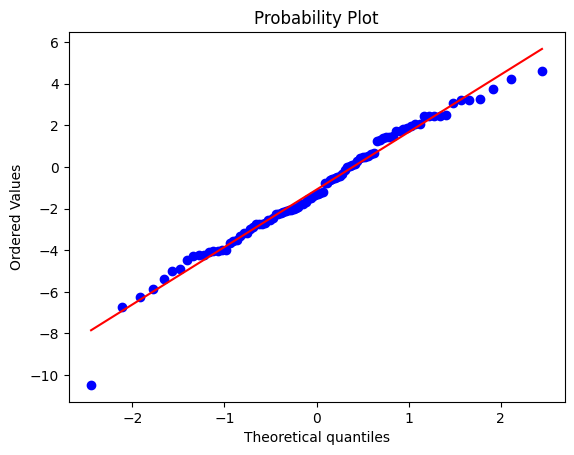

In [3]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import scipy.stats
scipy.stats.probplot(residuals, plot=plt)